In [30]:
import pickle
import pandas as pd
import numpy as np



file_path = "/kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD/S2/S2.pkl"

#Load the dataset

with open(file_path, 'rb') as f:
    data = pickle.load(f, encoding='latin1')

print("✅ Dataset loaded successfully!")
print("Top-level keys:", data.keys())


# Extract the signals from chest sensors

chest = data['signal']['chest']

# Available signals
print("\nAvailable chest signals:", chest.keys())

# Extract ECG, EDA, EMG
ecg = chest['ECG']
eda = chest['EDA']
emg = chest['EMG']


# Convert to DataFrame

df = pd.DataFrame({
    'ECG': ecg.flatten(),
    'EDA': eda.flatten(),
    'EMG': emg.flatten()
})

print("\n✅ DataFrame created successfully!")
print(df.head())


 #Handle missing/noisy values (basic cleaning)

# Replace NaNs with interpolation
df = df.interpolate(method='linear')

#Apply rolling mean smoothing Option
df = df.rolling(window=5, min_periods=1).mean()

print("\n✅ Cleaned data preview:")
print(df.head())


# STEP 6: Save to CSV

df.to_csv("/kaggle/working/S2_cleaned_signals.csv", index=False)
print("\n✅ File saved as 'S2_cleaned_signals.csv' in /kaggle/working/")


✅ Dataset loaded successfully!
Top-level keys: dict_keys(['signal', 'label', 'subject'])

Available chest signals: dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])

✅ DataFrame created successfully!
        ECG       EDA       EMG
0  0.021423  5.250549 -0.004440
1  0.020325  5.267334  0.004349
2  0.016525  5.243301  0.005173
3  0.016708  5.249405  0.007187
4  0.011673  5.286407 -0.015152

✅ Cleaned data preview:
        ECG       EDA       EMG
0  0.021423  5.250549 -0.004440
1  0.020874  5.258942 -0.000046
2  0.019424  5.253728  0.001694
3  0.018745  5.252647  0.003067
4  0.017331  5.259399 -0.000577

✅ File saved as 'S2_cleaned_signals.csv' in /kaggle/working/


In [31]:

# DATA PREPROCESSING & STATISTICAL ANALYSIS


import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt

print(" Starting preprocessing tasks...")


#  Load cleaned data 

file_path = "/kaggle/working/S2_cleaned_signals.csv" 
df = pd.read_csv(file_path)

print("✅ Cleaned data loaded successfully!")
print("Shape:", df.shape)
print(df.head(), "\n")


#  Interpolation (for any remaining gaps)

df = df.interpolate(method='linear', limit_direction='both')
print("✅ Interpolation completed!\n")


#   (Noise Reduction)

def butter_lowpass_filter(data, cutoff=3, fs=700, order=5):
    
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

for sig in ['ECG', 'EDA', 'EMG']:
    df[f'{sig}_filtered'] = butter_lowpass_filter(df[sig])
print("✅ Filtering completed!\n")

#  Smoothing (Rolling Mean)

for sig in ['ECG_filtered', 'EDA_filtered', 'EMG_filtered']:
    df[f'{sig}_smooth'] = df[sig].rolling(window=10, min_periods=1).mean()
print("✅ Smoothing completed!\n")


#  Rolling Statistics (Trend & Variability)

for sig in ['ECG_filtered', 'EDA_filtered', 'EMG_filtered']:
    df[f'{sig}_roll_mean'] = df[sig].rolling(window=50).mean()
    df[f'{sig}_roll_std']  = df[sig].rolling(window=50).std()
print("✅ Rolling mean and std calculated!\n")


#  Descriptive Statistics

desc_stats = df[['ECG', 'EDA', 'EMG']].describe().T
desc_stats['skewness'] = df[['ECG','EDA','EMG']].skew().values
desc_stats['kurtosis'] = df[['ECG','EDA','EMG']].kurt().values

desc_stats.to_csv("/kaggle/working/S2_descriptive_stats.csv")
print("✅ Descriptive statistics file saved!\n")


#  Save Final Processed Data

df.to_csv("/kaggle/working/S2_processed_signals.csv", index=False)
print("✅ Processed data saved as 'S2_processed_signals.csv'\n")


# Display Summary

print("📊 Descriptive Statistics Summary:\n")
print(desc_stats)

print("Files generated:")
print(" - S2_processed_signals.csv")
print(" - S2_descriptive_stats.csv")


 Starting preprocessing tasks...
✅ Cleaned data loaded successfully!
Shape: (4255300, 3)
        ECG       EDA       EMG
0  0.021423  5.250549 -0.004440
1  0.020874  5.258942 -0.000046
2  0.019424  5.253728  0.001694
3  0.018745  5.252647  0.003067
4  0.017331  5.259399 -0.000577 

✅ Interpolation completed!

✅ Filtering completed!

✅ Smoothing completed!

✅ Rolling mean and std calculated!

✅ Descriptive statistics file saved!

✅ Processed data saved as 'S2_processed_signals.csv'

📊 Descriptive Statistics Summary:

         count      mean       std       min       25%       50%       75%  \
ECG  4255300.0  0.001212  0.152722 -1.499478 -0.067346  0.008560  0.044193   
EDA  4255300.0  1.528390  1.238316  0.350189  0.795441  1.161880  1.546097   
EMG  4255300.0 -0.002413  0.007940 -0.259973 -0.005740 -0.002179  0.001282   

          max  skewness   kurtosis  
ECG  1.499194  1.162377  12.753175  
EDA  7.498093  2.346111   5.241574  
EMG  0.213245 -0.729064  10.928348  
Files generated:


✅ Data Loaded Successfully!
        ECG       EDA       EMG  ECG_filtered  EDA_filtered  EMG_filtered  \
0  0.021423  5.250549 -0.004440      0.031540      5.248698     -0.007163   
1  0.020874  5.258942 -0.000046      0.031744      5.248751     -0.007046   
2  0.019424  5.253728  0.001694      0.031967      5.248803     -0.006930   
3  0.018745  5.252647  0.003067      0.032207      5.248855     -0.006814   
4  0.017331  5.259399 -0.000577      0.032464      5.248906     -0.006699   

   ECG_filtered_smooth  EDA_filtered_smooth  EMG_filtered_smooth  \
0             0.031540             5.248698            -0.007163   
1             0.031642             5.248725            -0.007105   
2             0.031750             5.248751            -0.007047   
3             0.031864             5.248777            -0.006989   
4             0.031984             5.248803            -0.006931   

   ECG_filtered_roll_mean  ECG_filtered_roll_std  EDA_filtered_roll_mean  \
0                     Na

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning:

invalid value encountered in greater

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning:

invalid value encountered in less

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning:

invalid value encountered in greater



                ECG           EDA           EMG  ECG_filtered  EDA_filtered  \
count  4.255300e+06  4.255300e+06  4.255300e+06  4.255300e+06  4.255300e+06   
mean   1.212255e-03  1.528390e+00 -2.412909e-03  1.212313e-03  1.528390e+00   
std    1.527217e-01  1.238316e+00  7.939774e-03  9.045469e-02  1.238288e+00   
min   -1.499478e+00  3.501892e-01 -2.599731e-01 -1.400737e+00  3.672174e-01   
25%   -6.734619e-02  7.954407e-01 -5.740356e-03 -3.951927e-02  7.939525e-01   
50%    8.560181e-03  1.161880e+00 -2.178955e-03  1.137543e-02  1.161435e+00   
75%    4.419250e-02  1.546097e+00  1.281738e-03  5.303564e-02  1.546065e+00   
max    1.499194e+00  7.498093e+00  2.132446e-01  1.265552e+00  7.482525e+00   

       EMG_filtered  ECG_filtered_smooth  EDA_filtered_smooth  \
count  4.255300e+06         4.255300e+06         4.255300e+06   
mean  -2.412947e-03         1.212357e-03         1.528395e+00   
std    5.555396e-04         9.035643e-02         1.238294e+00   
min   -7.163346e-03        -

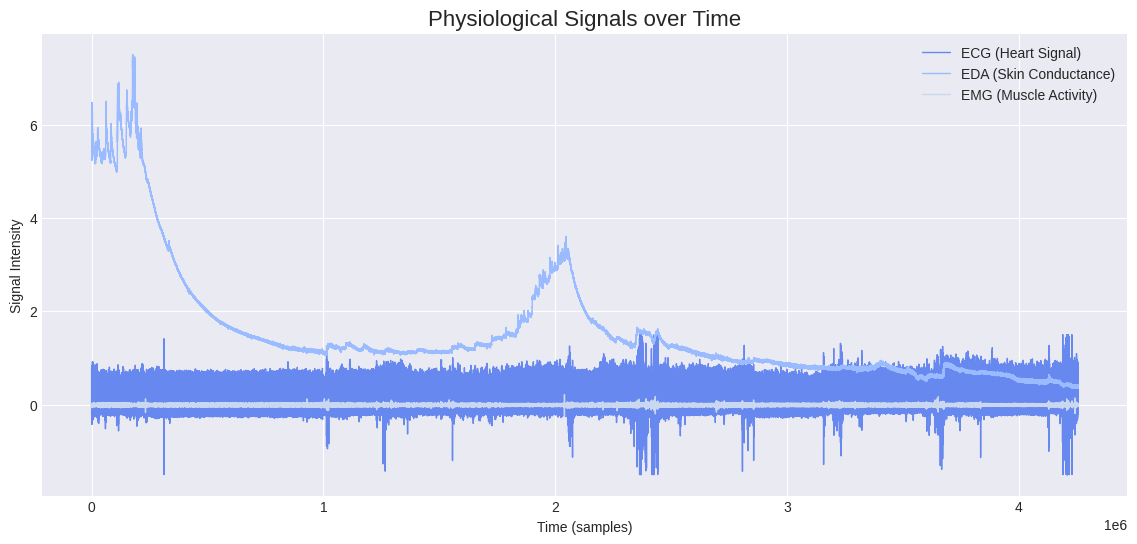

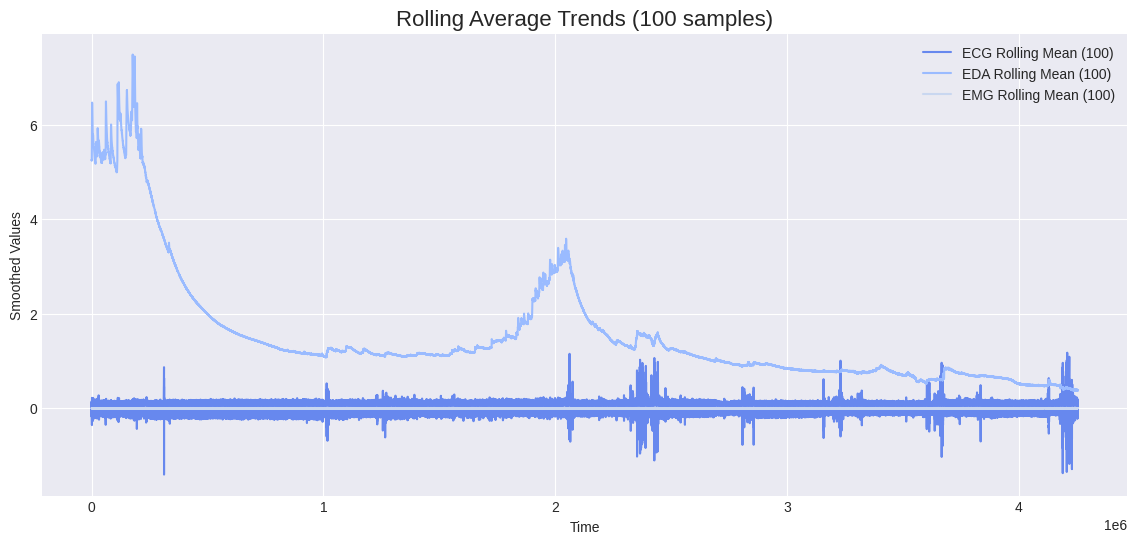

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



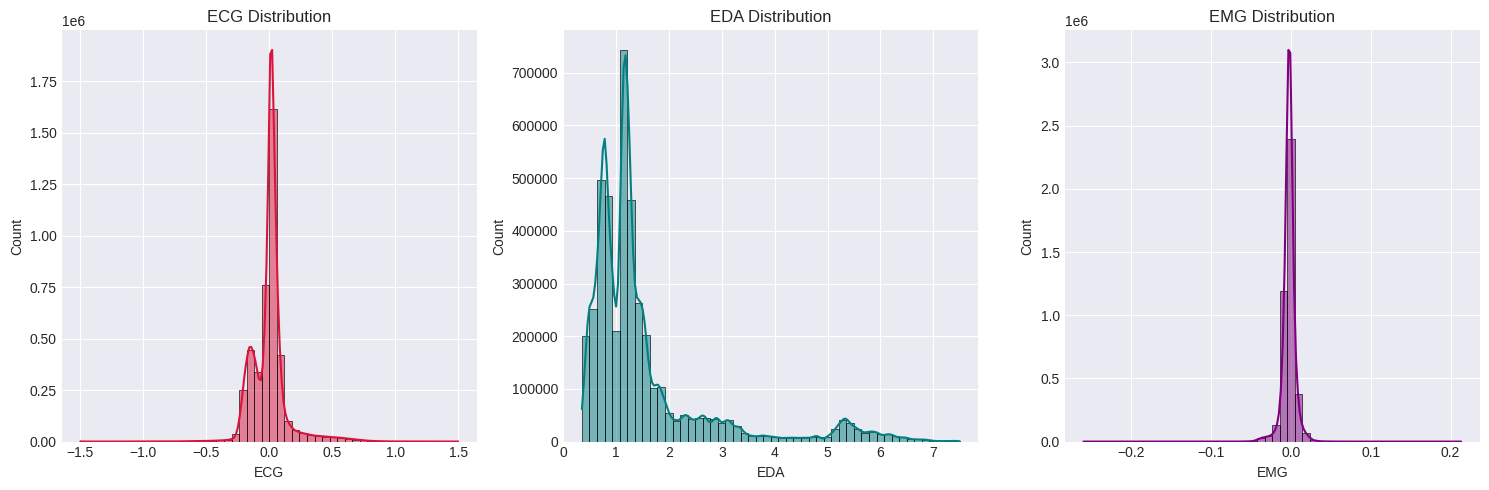

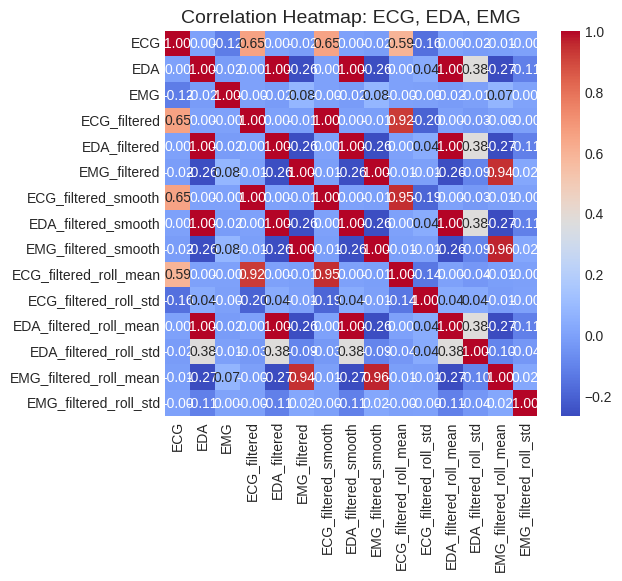

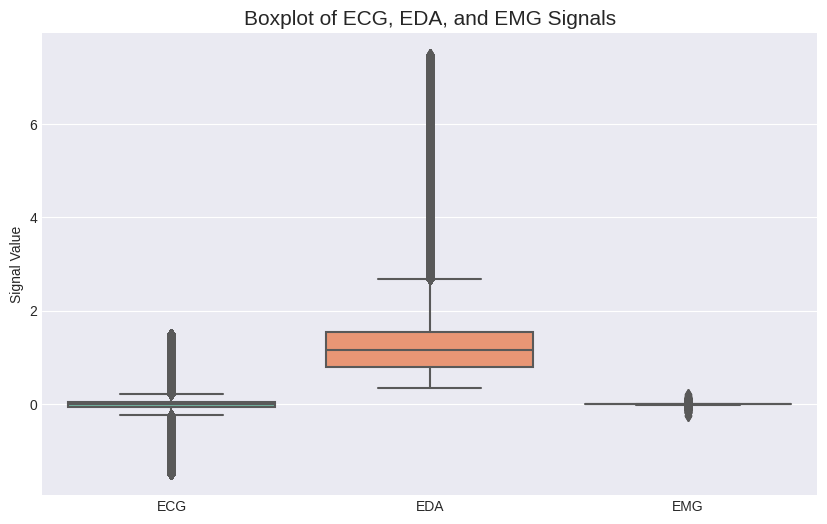

In [32]:

# 📊  Visualization Dashboard for WESAD S2 Data


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up  styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("coolwarm")
plt.rcParams['figure.figsize'] = (12, 6)


#  Load processed data

df = pd.read_csv("/kaggle/working/S2_processed_signals.csv")

print("✅ Data Loaded Successfully!")
print(df.head())


# STEP 2: Summary overview

print("\nData Summary:")
print(df.describe())


#  ECG, EDA, EMG line plots


# Plot all three signals
plt.figure(figsize=(14, 6))
plt.plot(df['ECG'], label='ECG (Heart Signal)', linewidth=1)
plt.plot(df['EDA'], label='EDA (Skin Conductance)', linewidth=1)
plt.plot(df['EMG'], label='EMG (Muscle Activity)', linewidth=1)
plt.title("Physiological Signals over Time", fontsize=16)
plt.xlabel("Time (samples)")
plt.ylabel("Signal Intensity")
plt.legend()
plt.show()


#  Rolling mean comparison (trend visualization)

window_size = 100
df_roll = df.rolling(window=window_size, min_periods=1).mean()

plt.figure(figsize=(14, 6))
plt.plot(df_roll['ECG'], label=f'ECG Rolling Mean ({window_size})')
plt.plot(df_roll['EDA'], label=f'EDA Rolling Mean ({window_size})')
plt.plot(df_roll['EMG'], label=f'EMG Rolling Mean ({window_size})')
plt.title(f"Rolling Average Trends ({window_size} samples)", fontsize=16)
plt.xlabel("Time")
plt.ylabel("Smoothed Values")
plt.legend()
plt.show()


# Distribution plots (histograms)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(df['ECG'], bins=50, kde=True, ax=axes[0], color='crimson')
axes[0].set_title("ECG Distribution")

sns.histplot(df['EDA'], bins=50, kde=True, ax=axes[1], color='teal')
axes[1].set_title("EDA Distribution")

sns.histplot(df['EMG'], bins=50, kde=True, ax=axes[2], color='purple')
axes[2].set_title("EMG Distribution")

plt.tight_layout()
plt.show()


#  Correlation heatmap

plt.figure(figsize=(6, 5))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap: ECG, EDA, EMG", fontsize=14)
plt.show()


# STEP 7: Boxplots (for outlier visualization)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['ECG', 'EDA', 'EMG']], palette='Set2')
plt.title("Boxplot of ECG, EDA, and EMG Signals", fontsize=15)
plt.ylabel("Signal Value")
plt.show()


#  Optional — Interactive (if using Plotly)

try:
    import plotly.express as px

    fig = px.line(df.iloc[:2000], 
                  y=['ECG', 'EDA', 'EMG'], 
                  title='Interactive Time Series (First 2000 Samples)',
                  labels={'value': 'Signal Value', 'index': 'Time'},
                  template='plotly_dark')
    fig.show()
except:
    print("Plotly not available — skipped interactive plot.")
